# [1] 교차검증과 하이퍼파라미터 튜닝

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Titanic 데이터 불러오기 (seaborn 내장)
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]
df['sex'] = df['sex'].map({'male':0, 'female':1})
df.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,0,22.0,7.2500,S
1,1,1,1,38.0,71.2833,C
2,1,3,1,26.0,7.9250,S
3,1,1,1,35.0,53.1000,S
4,0,3,0,35.0,8.0500,S


In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 19.2 MB/s eta 0:00:00


In [ ]:
# 분할
from sklearn.model_selection import train_test_split

In [ ]:
df.head(3)

,survived,pclass,sex,age,fare,embarked
0,0,3,0,22.0,7.2500,S
1,1,1,1,38.0,71.2833,C
2,1,3,1,26.0,7.9250,S


<Axes: ylabel='count'>

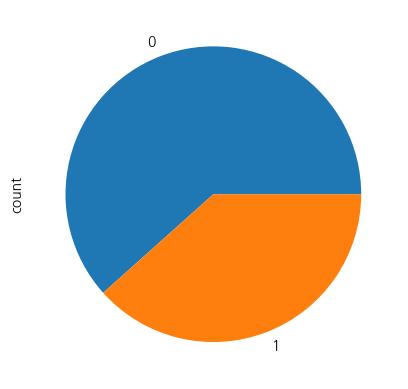

In [ ]:
df['survived'].value_counts().plot.pie()

In [ ]:
X = df.drop(['survived','embarked'],axis=1).copy()
y = df['survived'].copy()

In [ ]:
X_train, X_test, y_train, y_test  = train_test_split(X, y,
                                                     test_size=0.15,
                                                     stratify=y)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((757, 4), (134, 4), (757,), (134,))

## (1) 교차검증

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(random_state=42, max_depth=3)
scores = cross_val_score(model, X_train, y_train, scoring='f1', cv=5)

scores.mean()

np.float64(0.7075319866163042)

In [ ]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1')
print(f"평균 F1: {scores.mean():.4f} (±{scores.std():.4f})")

평균 F1: 0.7244 (±0.0523)


In [ ]:
model

RandomForestClassifier(max_depth=3, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(model, X_train, y_train, cv=skf)
y_pred

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,

In [ ]:
y_pred.shape

(757,)

In [ ]:
y_test.shape

(134,)

## (2) 하이퍼파라미터 튜닝

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

# 1. 모델 생성
model = XGBClassifier(random_state=42, eval_metric='logloss')

# 2. 탐색할 파라미터 그리드 정의
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
}

# 3. GridSearchCV 설정
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,                  # 5-fold 교차 검증
    scoring='f1',    # 평가 지표
    n_jobs=-1,             # 모든 CPU 코어 사용
    verbose=1              # 진행 상황 출력
)

# 4. 탐색 실행
grid_search.fit(X_train, y_train)

# 5. 결과 확인
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최적 CV 점수: {grid_search.best_score_:.4f}")

y_pred = grid_search.predict(X_test)

print(f"Test 점수: {f1_score(y_test, y_pred):.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
최적 파라미터: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 100}
최적 CV 점수: 0.7796
Test 점수: 0.6804


# [2] 실전! 앙상블 모델

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# 데이터 로딩
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target   # 0=악성(malignant), 1=양성(benign)

print(f"피처 수: {X.shape[1]}개 | 샘플 수: {X.shape[0]}개")
print(f"타겟 분포: 양성 {sum(y==1)}개, 악성 {sum(y==0)}개")

# 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

피처 수: 30개 | 샘플 수: 569개
타겟 분포: 양성 357개, 악성 212개
Train: (455, 30), Test: (114, 30)


## (1) 단순 모델 비교

In [ ]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'F1 Score': f1}
    print(f"[{name}] Accuracy: {acc:.4f} | F1: {f1:.4f}")

# DataFrame으로 비교
result_df = pd.DataFrame(results).T
result_df = result_df.sort_values('F1 Score', ascending=False)
print("\n📊 모델 성능 비교")
print(result_df)

[Random Forest] Accuracy: 0.9561 | F1: 0.9655
[XGBoost] Accuracy: 0.9561 | F1: 0.9660
[LightGBM] Accuracy: 0.9649 | F1: 0.9726

📊 모델 성능 비교
               Accuracy  F1 Score
LightGBM       0.964912  0.972603
XGBoost        0.956140  0.965986
Random Forest  0.956140  0.965517


## (2) 교차검증 확인

In [ ]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    cv_results[name] = {
        '평균 F1': scores.mean(),
        '표준편차': scores.std()
    }
    print(f"[{name}] F1: {scores.mean():.4f} (± {scores.std():.4f})")

cv_df = pd.DataFrame(cv_results).T
cv_df = cv_df.sort_values('평균 F1', ascending=False)
print("\n📊 교차검증 결과")
print(cv_df)

[Random Forest] F1: 0.9634 (± 0.0184)
[XGBoost] F1: 0.9704 (± 0.0170)
[LightGBM] F1: 0.9774 (± 0.0139)

📊 교차검증 결과
                  평균 F1      표준편차
LightGBM       0.977418  0.013924
XGBoost        0.970401  0.016956
Random Forest  0.963408  0.018366


## (3) Grid Search

In [ ]:
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1]
    },
    'LightGBM': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1]
    }
}

In [ ]:
best_models = {}
tuned_results = {}

for name, model in models.items():
    print(f"\n🔍 {name} 튜닝 중...")

    grid = GridSearchCV(
        model, param_grids[name],
        cv=5, scoring='f1', n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    y_pred = grid.best_estimator_.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    tuned_results[name] = {
        'Accuracy': acc,
        'F1 Score': f1,
        'Best Params': grid.best_params_
    }
    print(f"  최적 파라미터: {grid.best_params_}")
    print(f"  Accuracy: {acc:.4f} | F1: {f1:.4f}")

# 튜닝 전후 비교
print("\n" + "="*50)
print("📊 튜닝 전 vs 튜닝 후 F1 Score 비교")
print("="*50)
for name in models.keys():
    before = results[name]['F1 Score']
    after = tuned_results[name]['F1 Score']
    diff = after - before
    arrow = "⬆️" if diff > 0 else ("⬇️" if diff < 0 else "➡️")
    print(f"{name:15s} | 전: {before:.4f} → 후: {after:.4f} ({arrow} {diff:+.4f})")


🔍 Random Forest 튜닝 중...
  최적 파라미터: {'max_depth': 7, 'n_estimators': 200}
  Accuracy: 0.9474 | F1: 0.9583

🔍 XGBoost 튜닝 중...
  최적 파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Accuracy: 0.9474 | F1: 0.9589

🔍 LightGBM 튜닝 중...
  최적 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Accuracy: 0.9649 | F1: 0.9726

📊 튜닝 전 vs 튜닝 후 F1 Score 비교
Random Forest   | 전: 0.9655 → 후: 0.9583 (⬇️ -0.0072)
XGBoost         | 전: 0.9660 → 후: 0.9589 (⬇️ -0.0071)
LightGBM        | 전: 0.9726 → 후: 0.9726 (➡️ +0.0000)


In [ ]:
results

{'Random Forest': {'Accuracy': 0.956140350877193,
  'F1 Score': 0.9655172413793104},
 'XGBoost': {'Accuracy': 0.956140350877193, 'F1 Score': 0.9659863945578231},
 'LightGBM': {'Accuracy': 0.9649122807017544, 'F1 Score': 0.9726027397260274}}

## (4) 최종 해석 및 모델 선택

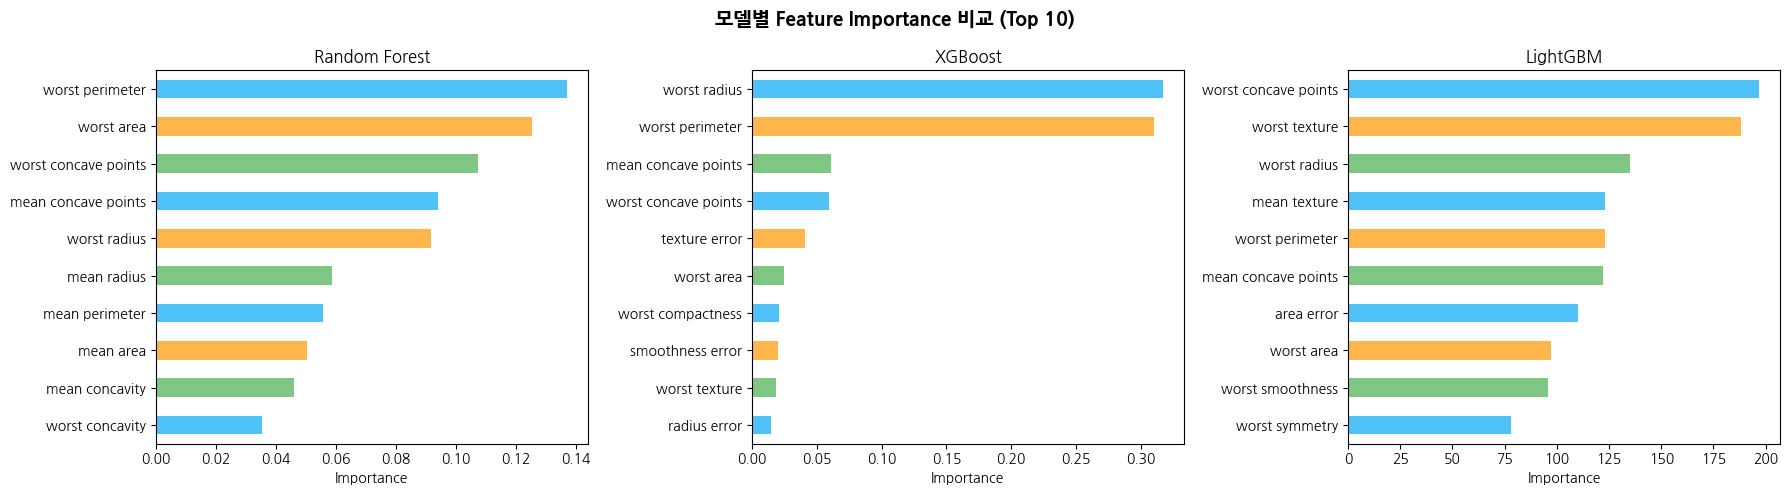

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(best_models.items()):
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=X_train.columns)
    feat_imp = feat_imp.sort_values(ascending=False).head(10)  # 상위 10개
    feat_imp = feat_imp.sort_values(ascending=True)  # 시각화용 정렬

    feat_imp.plot(kind='barh', ax=axes[idx], color=['#4FC3F7', '#81C784', '#FFB74D'])
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Importance')

plt.suptitle('모델별 Feature Importance 비교 (Top 10)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 최종 비교 테이블
print("="*60)
print("📋 최종 모델 비교 보고서")
print("="*60)

final_df = pd.DataFrame({
    name: {
        'Accuracy': tuned_results[name]['Accuracy'],
        'F1 Score': tuned_results[name]['F1 Score'],
    }
    for name in models.keys()
}).T
final_df = final_df.sort_values('F1 Score', ascending=False)
print(final_df)

# 최종 선택
best_name = final_df.index[0]
print(f"\n🏆 추천 모델: {best_name}")
print(f"   F1 Score: {final_df.loc[best_name, 'F1 Score']:.4f}")
print(f"   최적 파라미터: {tuned_results[best_name]['Best Params']}")

# 상세 리포트
y_pred_final = best_models[best_name].predict(X_test)
print(f"\n📊 {best_name} 상세 분류 리포트")
print(classification_report(y_test, y_pred_final, target_names=['악성(Malignant)', '양성(Benign)']))

📋 최종 모델 비교 보고서
               Accuracy  F1 Score
LightGBM       0.964912  0.972603
XGBoost        0.947368  0.958904
Random Forest  0.947368  0.958333

🏆 추천 모델: LightGBM
   F1 Score: 0.9726
   최적 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

📊 LightGBM 상세 분류 리포트
               precision    recall  f1-score   support

악성(Malignant)       0.97      0.93      0.95        42
   양성(Benign)       0.96      0.99      0.97        72

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



# [3] 피처 엔지니어링

In [ ]:
import pandas as pd
import numpy as np

# 새벽마켓 고객 데이터 (예시)
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'customer_id': [f'C{str(i).zfill(4)}' for i in range(1, n+1)],
    'age': np.random.randint(20, 60, n),
    'signup_date': pd.date_range('2023-01-01', periods=n, freq='12h'),
    'order_date': pd.date_range('2025-06-01', periods=n, freq='3h'),
    'last_order_date': pd.date_range('2025-12-01', periods=n, freq='5h'),
    'total_amount': np.random.exponential(50000, n).astype(int) + 5000,
    'order_count': np.random.poisson(8, n) + 1,
    'page_views': np.random.poisson(20, n) + 1,
    'avg_session_time': (np.random.exponential(5, n) + 0.5).round(1),
    'recent_purchases': np.random.poisson(2, n),
    'total_purchases': np.random.poisson(10, n) + 1,
})

df.head()

,customer_id,age,signup_date,order_date,last_order_date,total_amount,order_count,page_views,avg_session_time,recent_purchases,total_purchases
0,C0001,58,2023-01-01 00:00:00,2025-06-01 00:00:00,2025-12-01 00:00:00,61469,13,17,18.5,0,11
1,C0002,48,2023-01-01 12:00:00,2025-06-01 03:00:00,2025-12-01 05:00:00,37939,11,19,2.2,1,12
2,C0003,34,2023-01-02 00:00:00,2025-06-01 06:00:00,2025-12-01 10:00:00,38964,10,25,0.9,1,14
3,C0004,27,2023-01-02 12:00:00,2025-06-01 09:00:00,2025-12-01 15:00:00,9347,8,24,2.6,5,8
4,C0005,40,2023-01-03 00:00:00,2025-06-01 12:00:00,2025-12-01 20:00:00,9809,10,24,7.3,3,11


In [ ]:
df.dtypes

,0
customer_id,object
age,int64
signup_date,datetime64[ns]
order_date,datetime64[ns]
last_order_date,datetime64[ns]
total_amount,int64
order_count,int64
page_views,int64
avg_session_time,float64
recent_purchases,int64


## (1) 구간화 (Binning)

<Axes: xlabel='age', ylabel='Density'>

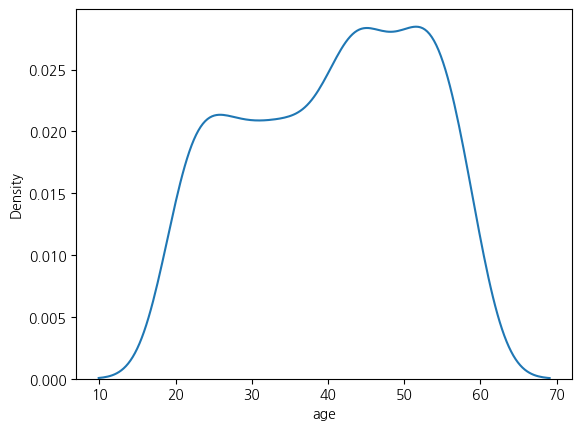

In [ ]:
sns.kdeplot(df['age'])

<Axes: xlabel='age', ylabel='Count'>

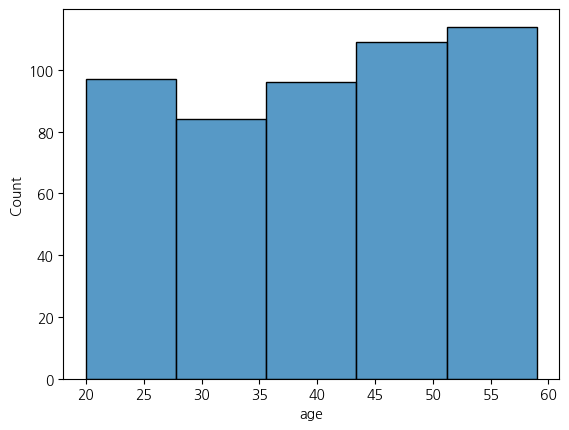

In [ ]:
sns.histplot(df['age'],bins=5)

In [ ]:
df.head()

,customer_id,age,signup_date,order_date,last_order_date,total_amount,order_count,page_views,avg_session_time,recent_purchases,total_purchases
0,C0001,58,2023-01-01 00:00:00,2025-06-01 00:00:00,2025-12-01 00:00:00,61469,13,17,18.5,0,11
1,C0002,48,2023-01-01 12:00:00,2025-06-01 03:00:00,2025-12-01 05:00:00,37939,11,19,2.2,1,12
2,C0003,34,2023-01-02 00:00:00,2025-06-01 06:00:00,2025-12-01 10:00:00,38964,10,25,0.9,1,14
3,C0004,27,2023-01-02 12:00:00,2025-06-01 09:00:00,2025-12-01 15:00:00,9347,8,24,2.6,5,8
4,C0005,40,2023-01-03 00:00:00,2025-06-01 12:00:00,2025-12-01 20:00:00,9809,10,24,7.3,3,11


In [ ]:
# 구간 경계값을 직접 지정
df['age_age'] = pd.cut(df['age'],
                       bins=[0,19,29,39,49,100],
                       labels=['10대','20대','30대','40대','50대+'])

In [ ]:
df['age_age'].value_counts()

,count
age_age,
40대,141
50대+,139
20대,115
30대,105
10대,0


In [ ]:
df['total_amount']

,total_amount
0,61469
1,37939
2,38964
3,9347
4,9809
...,...
495,54009
496,25463
497,92179
498,27553


In [ ]:
df['total_amount'].quantile(q=[0.25,0.5,0.75,1])

,total_amount
0.25,21207.75
0.50,42917.00
0.75,74232.00
1.00,308582.00


In [ ]:
# 구간화 -> 데이터 사분위수 기반
df['amount_grade'] = pd.qcut(df['total_amount'],
                            q=4,
                            labels=['Bronze','Silver','Gold','Platinum'])

In [ ]:
df['amount_grade'].value_counts()

,count
amount_grade,
Bronze,125
Silver,125
Gold,125
Platinum,125


## (2) 수학적 변환

<Axes: xlabel='total_amount', ylabel='Density'>

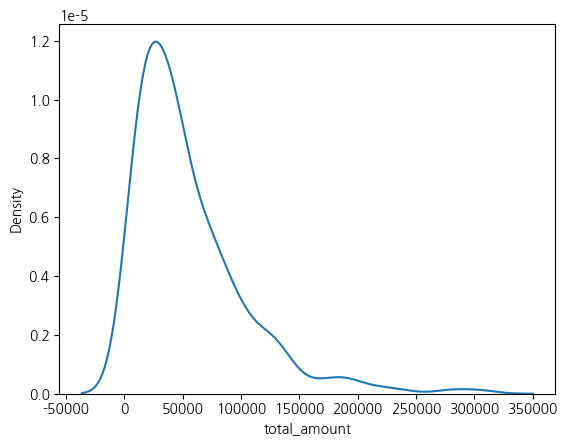

In [ ]:
sns.kdeplot(df['total_amount'])

In [ ]:
import numpy as np


df['log_amount'] = np.log1p(df['total_amount'])

<Axes: xlabel='log_amount', ylabel='Density'>

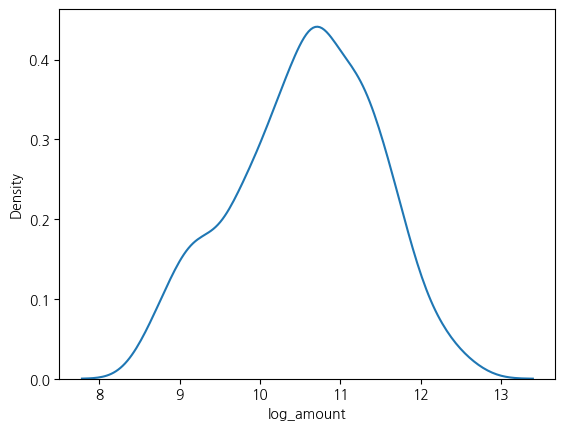

In [ ]:
sns.kdeplot(df['log_amount'])

<Axes: xlabel='log_amount', ylabel='Density'>

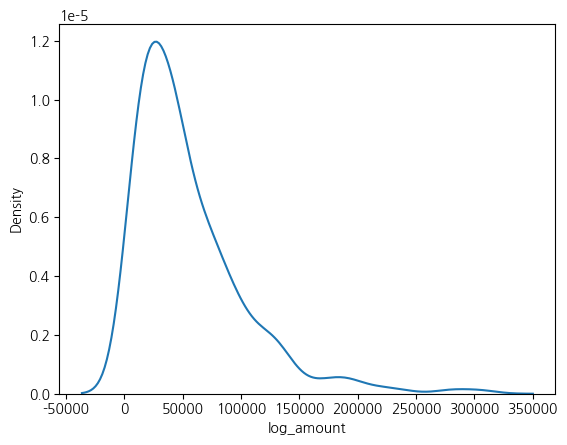

In [ ]:
# 다시 되돌리기 가능!
sns.kdeplot(np.expm1(df['log_amount']))

## (3) 교차 피처

In [ ]:
df.head()

,customer_id,age,signup_date,order_date,last_order_date,total_amount,order_count,page_views,avg_session_time,recent_purchases,total_purchases,age_age,amount_grade,log_amount
0,C0001,58,2023-01-01 00:00:00,2025-06-01 00:00:00,2025-12-01 00:00:00,61469,13,17,18.5,0,11,50대+,Gold,11.026305
1,C0002,48,2023-01-01 12:00:00,2025-06-01 03:00:00,2025-12-01 05:00:00,37939,11,19,2.2,1,12,40대,Silver,10.543761
2,C0003,34,2023-01-02 00:00:00,2025-06-01 06:00:00,2025-12-01 10:00:00,38964,10,25,0.9,1,14,30대,Silver,10.570419
3,C0004,27,2023-01-02 12:00:00,2025-06-01 09:00:00,2025-12-01 15:00:00,9347,8,24,2.6,5,8,20대,Bronze,9.142918
4,C0005,40,2023-01-03 00:00:00,2025-06-01 12:00:00,2025-12-01 20:00:00,9809,10,24,7.3,3,11,40대,Bronze,9.191158


In [ ]:
df['avg_order_value'] = (df['total_amount'] / df['order_count']).map(round)

In [ ]:
df['engagement_score'] = df['avg_session_time'] * df['page_views']

In [ ]:
df['recent_ratio'] = df['recent_purchases'] / (df['total_purchases'] + 1)

In [ ]:
df['recent_ratio']

,recent_ratio
0,0.000000
1,0.076923
2,0.066667
3,0.555556
4,0.250000
...,...
495,0.333333
496,0.055556
497,0.076923
498,0.090909


## (4) 날짜 파생 변수

In [ ]:
df.dtypes

,0
customer_id,object
age,int64
signup_date,datetime64[ns]
order_date,datetime64[ns]
last_order_date,datetime64[ns]
total_amount,int64
order_count,int64
page_views,int64
avg_session_time,float64
recent_purchases,int64


In [ ]:
df['day_of_week'] = df['order_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [ ]:
df['is_weekend'].value_counts()

,count
is_weekend,
0,360
1,140


## (5) 피처 제거

In [ ]:
df['signup_year'] = df['signup_date'].dt.year.astype(int)
df['signup_year'].value_counts()

,count
signup_year,
2023,500


In [ ]:
df['signup_year'].var()

0.0

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.1)
X_selected = selector.fit_transform(df.select_dtypes('number'))

In [ ]:
removed = df.select_dtypes('number').columns[~selector.get_support()].tolist()
removed

['recent_ratio', 'signup_year']

In [ ]:
df['recent_ratio'].var()

0.02246834989472105

In [ ]:
df['recent_ratio'].describe()

,recent_ratio
count,500.000000
mean,0.178691
std,0.149894
min,0.000000
25%,0.076923
50%,0.153846
75%,0.250000
max,0.714286


In [ ]:
selector.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True, False])

In [ ]:
df.select_dtypes('number').columns

Index(['age', 'total_amount', 'order_count', 'page_views', 'avg_session_time',
       'recent_purchases', 'total_purchases', 'log_amount', 'avg_order_value',
       'engagement_score', 'recent_ratio', 'day_of_week', 'is_weekend',
       'signup_year'],
      dtype='object')

# [4] 실전! 피처 엔지니어링

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('deal_data.csv')

print(f"데이터 크기: {df.shape}")
print(f"\n타겟 분포:")
print(df['deal_success'].value_counts())
print(f"\n거래 성사율: {df['deal_success'].mean()*100:.1f}%\n")
df.head()

데이터 크기: (2000, 11)

타겟 분포:
deal_success
0    1013
1     987
Name: count, dtype: int64

거래 성사율: 49.4%



,user_id,user_age,signup_date,item_price,item_category,description_length,photo_count,page_views,chat_count,last_login_date,deal_success
0,U0001,56,2024-01-01,150353,전자기기,167,7,33,5,2025-06-01,0
1,U0002,46,2024-01-01,15016,기타,213,7,49,2,2025-06-01,0
2,U0003,32,2024-01-01,18348,전자기기,205,5,28,2,2025-06-01,0
3,U0004,60,2024-01-01,19527,전자기기,225,5,39,6,2025-06-01,0
4,U0005,25,2024-01-01,23810,전자기기,294,4,32,2,2025-06-01,0


## (1) Baseline 모델

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_base = df.copy()
le = LabelEncoder()
df_base['item_category_enc'] = le.fit_transform(df_base['item_category'])


In [ ]:
df_base.head()

,user_id,user_age,signup_date,item_price,item_category,description_length,photo_count,page_views,chat_count,last_login_date,deal_success,item_category_enc
0,U0001,56,2024-01-01,150353,전자기기,167,7,33,5,2025-06-01,0,4
1,U0002,46,2024-01-01,15016,기타,213,7,49,2,2025-06-01,0,1
2,U0003,32,2024-01-01,18348,전자기기,205,5,28,2,2025-06-01,0,4
3,U0004,60,2024-01-01,19527,전자기기,225,5,39,6,2025-06-01,0,4
4,U0005,25,2024-01-01,23810,전자기기,294,4,32,2,2025-06-01,0,4


In [ ]:
cols = ['user_age', 'item_price',
       'description_length', 'photo_count',
        'page_views', 'chat_count',
        'deal_success']

X = df_base[cols]
y = df_base['deal_success']

In [ ]:
X.shape

(2000, 7)

In [ ]:
y.shape

(2000,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                test_size=0.2, random_state=42, stratify=y)

In [ ]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_base = rf_base.predict(X_test)

In [ ]:
from sklearn.metrics import f1_score, classification_report

f1_score(y_test, y_pred_base)

1.0

In [ ]:
print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       203
           1       1.00      1.00      1.00       197

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [ ]:
baseline_f1 = f1_score(y_test, y_pred_base)
print(f"\n📊 Baseline F1 Score: {baseline_f1:.4f}")
print(f"\n{classification_report(y_test, y_pred_base, target_names=['미성사', '성사'])}")


📊 Baseline F1 Score: 1.0000

              precision    recall  f1-score   support

         미성사       1.00      1.00      1.00       203
          성사       1.00      1.00      1.00       197

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [ ]:
# 피처 준비
df_base = df.copy()

# 범주형 인코딩
le = LabelEncoder()
df_base['item_category_enc'] = le.fit_transform(df_base['item_category'])

# 피처 선택 (raw 피처만, 날짜 제외)
features_raw = ['user_age', 'item_price',
                'description_length', 'photo_count',
                'page_views', 'chat_count', 'item_category_enc']
X = df_base[features_raw]
y = df_base['deal_success']

# 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline 모델
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

baseline_f1 = f1_score(y_test, y_pred_base)
print(f"\n📊 Baseline F1 Score: {baseline_f1:.4f}")
print(f"\n{classification_report(y_test, y_pred_base, target_names=['미성사', '성사'])}")


📊 Baseline F1 Score: 0.5450

              precision    recall  f1-score   support

         미성사       0.57      0.62      0.59       203
          성사       0.57      0.52      0.54       197

    accuracy                           0.57       400
   macro avg       0.57      0.57      0.57       400
weighted avg       0.57      0.57      0.57       400



## (2) 날짜 파생변수

In [ ]:
df_fe = df.copy()
df_fe.head()

,user_id,user_age,signup_date,item_price,item_category,description_length,photo_count,page_views,chat_count,last_login_date,deal_success
0,U0001,56,2024-01-01,150353,전자기기,167,7,33,5,2025-06-01,0
1,U0002,46,2024-01-01,15016,기타,213,7,49,2,2025-06-01,0
2,U0003,32,2024-01-01,18348,전자기기,205,5,28,2,2025-06-01,0
3,U0004,60,2024-01-01,19527,전자기기,225,5,39,6,2025-06-01,0
4,U0005,25,2024-01-01,23810,전자기기,294,4,32,2,2025-06-01,0


In [ ]:
df_fe.dtypes

,0
user_id,object
user_age,int64
signup_date,object
item_price,int64
item_category,object
description_length,int64
photo_count,int64
page_views,int64
chat_count,int64
last_login_date,object


In [ ]:
df_fe['signup_date'] = pd.to_datetime(df_fe['signup_date'])
df_fe['last_login_date'] = pd.to_datetime(df_fe['last_login_date'])

In [ ]:
df_fe.dtypes

,0
user_id,object
user_age,int64
signup_date,datetime64[ns]
item_price,int64
item_category,object
description_length,int64
photo_count,int64
page_views,int64
chat_count,int64
last_login_date,datetime64[ns]


In [ ]:
date = pd.Timestamp('2026-03-17')

df_fe['days_since_signup'] = (date - df_fe['signup_date']).dt.days
df_fe['days_since_login'] = (date - df_fe['last_login_date']).dt.days
df_fe['login_dayofweek'] = df_fe['last_login_date'].dt.dayofweek

In [ ]:
df_fe.head()

,user_id,user_age,signup_date,item_price,item_category,description_length,photo_count,page_views,chat_count,last_login_date,deal_success,days_since_signup,days_since_login,login_dayofweek
0,U0001,56,2024-01-01,150353,전자기기,167,7,33,5,2025-06-01,0,806,289,6
1,U0002,46,2024-01-01,15016,기타,213,7,49,2,2025-06-01,0,806,289,6
2,U0003,32,2024-01-01,18348,전자기기,205,5,28,2,2025-06-01,0,806,289,6
3,U0004,60,2024-01-01,19527,전자기기,225,5,39,6,2025-06-01,0,806,289,6
4,U0005,25,2024-01-01,23810,전자기기,294,4,32,2,2025-06-01,0,806,289,6


## (3) 교차 피처

In [ ]:
df_fe['conversion_rate'] = df_fe['chat_count'] / (df_fe['page_views'] + 1)
df_fe['interest_score'] = df_fe['chat_count'] * df_fe['item_price'] / 10000

In [ ]:
df_fe['conversion_rate'].describe()

,conversion_rate
count,2000.000000
mean,0.098674
std,0.060570
min,0.000000
25%,0.055556
50%,0.090909
75%,0.133333
max,0.400000


## (4) 로그 변환

In [ ]:
df_fe['item_price_log'] = np.log1p(df_fe['item_price'])

<Axes: xlabel='item_price', ylabel='Density'>

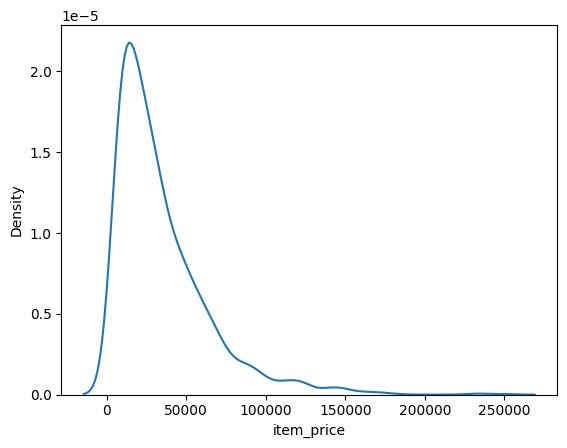

In [ ]:
import seaborn as sns
sns.kdeplot(df_fe['item_price'])

<Axes: xlabel='item_price_log', ylabel='Density'>

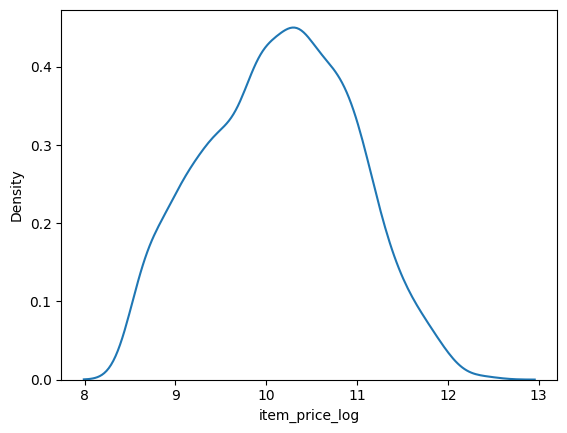

In [ ]:
sns.kdeplot(df_fe['item_price_log'])

## (5) 구간화

In [ ]:
# pd.cut()으로 18~24, 25~34, 35~44, 45+

df_fe['age_group'] = pd.cut(df_fe['user_age'],bins=[0,24,34,44,100],labels=[0,1,2,3])

In [ ]:
df_fe['age_group'].value_counts()

,count
age_group,
3,898
2,415
1,406
0,281


## (6) 성능 비교

In [ ]:
# 인코딩
le = LabelEncoder()
df_fe['item_category_enc'] = le.fit_transform(df_fe['item_category'])

# FE 적용 피처 리스트
features_fe = [
    # raw 피처
    'user_age', 'item_price', 'description_length', 'photo_count',
    'page_views', 'chat_count', 'item_category_enc',
    # 파생변수
    'days_since_signup', 'days_since_login', 'login_dayofweek',
    'conversion_rate', 'interest_score', 'item_price_log', 'age_group'
]

X_fe = df_fe[features_fe]
y = df_fe['deal_success']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.2, random_state=42, stratify=y
)

rf_fe = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = rf_fe.predict(X_test_fe)

fe_f1 = f1_score(y_test_fe, y_pred_fe)

print("="*50)
print("📊 피처 엔지니어링 전후 F1 Score 비교")
print("="*50)
print(f"Baseline (raw 피처):      F1 = {baseline_f1:.4f}")
print(f"FE 적용 후:              F1 = {fe_f1:.4f}")
print(f"향상:                   +{fe_f1 - baseline_f1:.4f}")

print(f"\n📝 FE 적용 후 상세 리포트:")
print(classification_report(y_test_fe, y_pred_fe, target_names=['미성사', '성사']))

📊 피처 엔지니어링 전후 F1 Score 비교
Baseline (raw 피처):      F1 = 0.5450
FE 적용 후:              F1 = 0.8951
향상:                   +0.3502

📝 FE 적용 후 상세 리포트:
              precision    recall  f1-score   support

         미성사       0.89      0.91      0.90       203
          성사       0.90      0.89      0.90       197

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



## (7) 해석

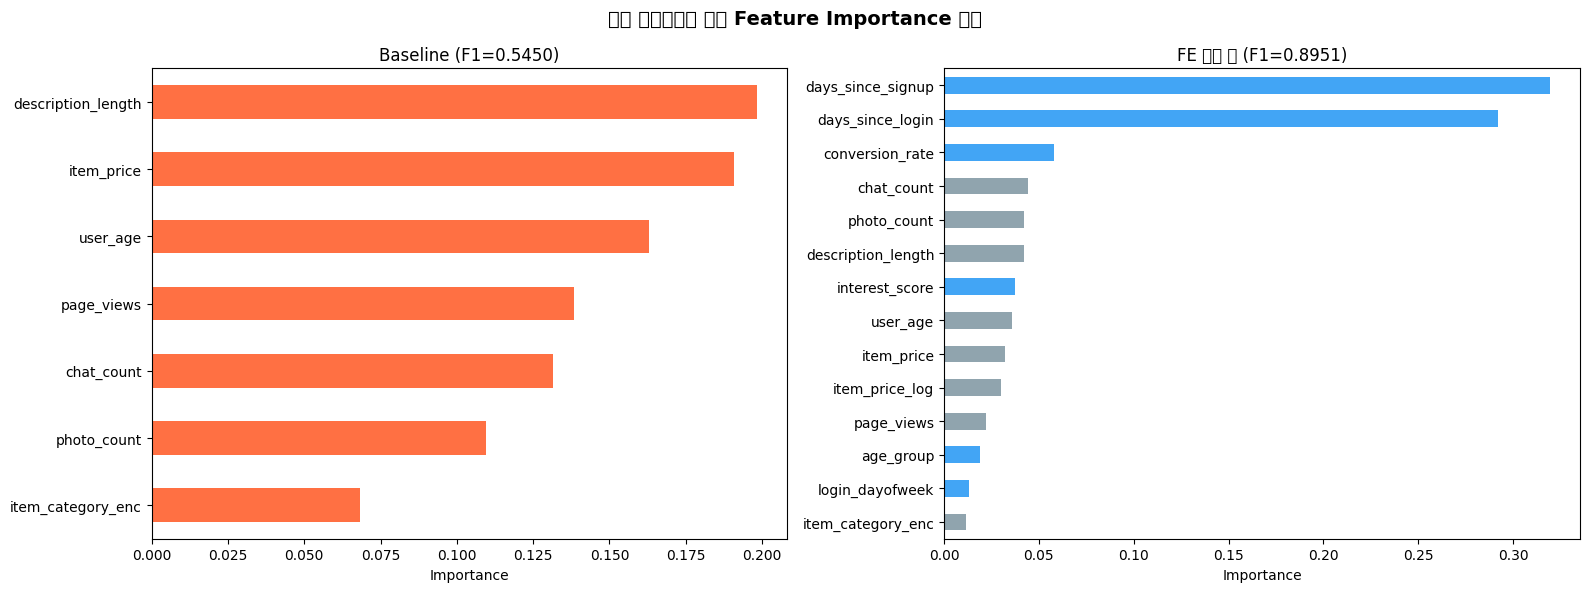


파란색 = 새로 만든 피처, 회색 = 기존 피처

📝 FE 모델 상위 5개 피처:
days_since_signup    0.319371
days_since_login     0.291867
conversion_rate      0.058091
chat_count           0.044342
photo_count          0.042212
dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline FI
imp_base = pd.Series(rf_base.feature_importances_, index=features_raw)
imp_base = imp_base.sort_values(ascending=True)
imp_base.plot(kind='barh', ax=axes[0], color='#FF7043')
axes[0].set_title(f'Baseline (F1={baseline_f1:.4f})')
axes[0].set_xlabel('Importance')

# FE FI
imp_fe = pd.Series(rf_fe.feature_importances_, index=features_fe)
imp_fe = imp_fe.sort_values(ascending=True)

# 파생변수 강조
colors = ['#42A5F5' if f in ['days_since_signup', 'days_since_login', 'login_dayofweek',
                              'conversion_rate', 'interest_score', 'log_price', 'age_group']
          else '#90A4AE' for f in imp_fe.index]
imp_fe.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title(f'FE 적용 후 (F1={fe_f1:.4f})')
axes[1].set_xlabel('Importance')

plt.suptitle('피처 엔지니어링 전후 Feature Importance 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n파란색 = 새로 만든 피처, 회색 = 기존 피처")
print("\n📝 FE 모델 상위 5개 피처:")
print(imp_fe.sort_values(ascending=False).head())

# [5] 정규화 회귀

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# 데이터 로딩
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# 스케일링 (정규화 회귀에 필수!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.01)': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5)
}

print(f"{'모델':<25} {'Train R²':>10} {'Test R²':>10} {'Test RMSE':>10}")
print("=" * 57)

for name, model in models.items():
    model.fit(X_train, y_train)

    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"{name:<25} {train_r2:>10.4f} {test_r2:>10.4f} {rmse:>10.4f}")

모델                          Train R²    Test R²  Test RMSE
LinearRegression              0.6126     0.5758     0.7456
Ridge (α=1.0)                 0.6126     0.5758     0.7456
Lasso (α=0.01)                0.6082     0.5819     0.7402
ElasticNet                    0.6100     0.5806     0.7413


In [ ]:
# Lasso가 어떤 피처를 살리고 죽였는지 확인
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

coef_df = pd.DataFrame({
    '피처': housing.feature_names,
    '계수': lasso.coef_
})
coef_df['상태'] = coef_df['계수'].apply(lambda x: '✅ 살아남음' if abs(x) > 0.001 else '❌ 제거됨')
coef_df = coef_df.sort_values('계수', key=abs, ascending=False)

print("\n📋 Lasso (α=0.1) 피처 선택 결과:")
print(coef_df.to_string(index=False))


📋 Lasso (α=0.1) 피처 선택 결과:
        피처        계수     상태
    MedInc  0.709186 ✅ 살아남음
  HouseAge  0.106475 ✅ 살아남음
  Latitude -0.011479 ✅ 살아남음
  AveRooms -0.000000  ❌ 제거됨
 AveBedrms  0.000000  ❌ 제거됨
Population -0.000000  ❌ 제거됨
  AveOccup -0.000000  ❌ 제거됨
 Longitude -0.000000  ❌ 제거됨


In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV

# RidgeCV: 자동으로 최적 alpha 탐색
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge_cv.fit(X_train, y_train)

print(f"Ridge 최적 alpha: {ridge_cv.alpha_}")
print(f"Ridge Test R²: {ridge_cv.score(X_test, y_test):.4f}")

# LassoCV: 자동으로 최적 alpha 탐색
lasso_cv = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0], cv=5)
lasso_cv.fit(X_train, y_train)

print(f"\nLasso 최적 alpha: {lasso_cv.alpha_}")
print(f"Lasso Test R²: {lasso_cv.score(X_test, y_test):.4f}")

Ridge 최적 alpha: 0.1
Ridge Test R²: 0.5758

Lasso 최적 alpha: 0.001
Lasso Test R²: 0.5769


# [6] KNN

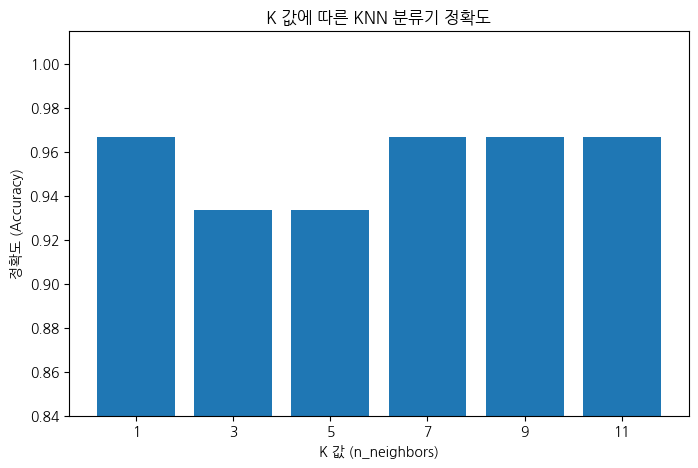

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 데이터 준비
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

# 스케일링 (KNN은 거리 기반이므로 필수!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# K값별 성능 비교
acc = []
ks = [1, 3, 5, 7, 9, 11]
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    acc.append(knn.score(X_test_s, y_test))

plt.figure(figsize=(8, 5))
plt.bar([str(k) for k in ks], acc)
plt.xlabel('K 값 (n_neighbors)')
plt.ylabel('정확도 (Accuracy)')
plt.title('K 값에 따른 KNN 분류기 정확도')
plt.ylim(min(acc) * 0.9, max(acc) * 1.05) # y축 범위 조정
plt.show()

# [7] 실전! 불균형 분류 실습

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Credit Card Fraud 스타일 데이터 생성 (99:1 불균형)
from sklearn.datasets import make_classification

X_raw, y_raw = make_classification(
    n_samples=10000, n_features=20, n_informative=10,
    n_redundant=5, weights=[0.99, 0.01],  # 99:1 불균형
    random_state=42
)

df = pd.DataFrame(X_raw, columns=[f'V{i+1}' for i in range(20)])
df['Class'] = y_raw

print(f"데이터 크기: {df.shape}")
print(f"\n클래스 분포:")
print(df['Class'].value_counts())
print(f"\n사기 비율: {df['Class'].mean()*100:.2f}%")

데이터 크기: (10000, 21)

클래스 분포:
Class
0    9859
1     141
Name: count, dtype: int64

사기 비율: 1.41%


In [ ]:
df.head(2)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V12,V13,V14,V15,V16,V17,V18,V19,V20,Class
0,1.716809,0.413473,-1.142711,-4.066260,0.938451,0.038839,-4.540817,-1.254791,-0.193970,-0.688750,...,0.700254,-0.136394,0.693104,1.176857,2.607634,-1.442199,0.370059,0.410418,1.393320,0
1,-1.368954,1.111770,2.869476,-2.498132,-1.120054,0.754516,-1.267701,3.345535,0.749588,0.168166,...,-0.967787,-1.781184,2.995910,-2.391062,1.604645,-3.333805,0.564148,-0.261230,0.813225,0


## (1) 학습/테스트 분리

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y    # 불균형 비율 유지!
)

# 스케일링
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)         # 테스트는 transform만!

print(f"학습 데이터 클래스 분포:")
print(pd.Series(y_train).value_counts())
print(f"\n테스트 데이터 클래스 분포:")
print(pd.Series(y_test).value_counts())

학습 데이터 클래스 분포:
Class
0    7887
1     113
Name: count, dtype: int64

테스트 데이터 클래스 분포:
Class
0    1972
1      28
Name: count, dtype: int64


In [ ]:
print(f"학습 데이터 클래스 분포:")
print(pd.Series(y_train).value_counts(normalize=True))
print(f"\n테스트 데이터 클래스 분포:")
print(pd.Series(y_test).value_counts(normalize=True))

학습 데이터 클래스 분포:
Class
0    0.985875
1    0.014125
Name: proportion, dtype: float64

테스트 데이터 클래스 분포:
Class
0    0.986
1    0.014
Name: proportion, dtype: float64


## (2) 기준선 : 아무 처리 없이

In [ ]:
# 전략 1: 아무 처리 없이
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_s, y_train)
y_pred_base = rf_base.predict(X_test_s)

print("📋 전략 1: 처리 없음")
print(f"Accuracy: {rf_base.score(X_test_s, y_test):.4f}")
print(f"F1 (사기): {f1_score(y_test, y_pred_base):.4f}")
print(classification_report(y_test, y_pred_base, target_names=['정상', '사기']))

📋 전략 1: 처리 없음
Accuracy: 0.9870
F1 (사기): 0.1333
              precision    recall  f1-score   support

          정상       0.99      1.00      0.99      1972
          사기       1.00      0.07      0.13        28

    accuracy                           0.99      2000
   macro avg       0.99      0.54      0.56      2000
weighted avg       0.99      0.99      0.98      2000



## (3) class_weight='balanced'


In [ ]:
# 전략 2: class_weight='balanced'
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',      # 클래스 가중치 자동 설정
    random_state=42
)
rf_balanced.fit(X_train_s, y_train)
y_pred_bal = rf_balanced.predict(X_test_s)

print("\n📋 전략 2: class_weight='balanced'")
print(f"Accuracy: {rf_balanced.score(X_test_s, y_test):.4f}")
print(f"F1 (사기): {f1_score(y_test, y_pred_bal):.4f}")
print(classification_report(y_test, y_pred_bal, target_names=['정상', '사기']))


📋 전략 2: class_weight='balanced'
Accuracy: 0.9865
F1 (사기): 0.0690
              precision    recall  f1-score   support

          정상       0.99      1.00      0.99      1972
          사기       1.00      0.04      0.07        28

    accuracy                           0.99      2000
   macro avg       0.99      0.52      0.53      2000
weighted avg       0.99      0.99      0.98      2000



## (4) SMOTE 오버샘플링

In [ ]:
# pip install imbalanced-learn  (설치 필요)
from imblearn.over_sampling import SMOTE

# 학습 데이터에만 SMOTE 적용!
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"SMOTE 전: {pd.Series(y_train).value_counts().to_dict()}")
print(f"SMOTE 후: {pd.Series(y_train_sm).value_counts().to_dict()}")

# SMOTE 데이터로 학습
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_sm = rf_smote.predict(X_test_s)    # 테스트는 원본 그대로!

print("\n📋 전략 3: SMOTE")
print(f"Accuracy: {rf_smote.score(X_test_s, y_test):.4f}")
print(f"F1 (사기): {f1_score(y_test, y_pred_sm):.4f}")
print(classification_report(y_test, y_pred_sm, target_names=['정상', '사기']))

SMOTE 전: {0: 7887, 1: 113}
SMOTE 후: {0: 7887, 1: 7887}

📋 전략 3: SMOTE
Accuracy: 0.9695
F1 (사기): 0.2078
              precision    recall  f1-score   support

          정상       0.99      0.98      0.98      1972
          사기       0.16      0.29      0.21        28

    accuracy                           0.97      2000
   macro avg       0.58      0.63      0.60      2000
weighted avg       0.98      0.97      0.97      2000



## (5) 세 전략 비교

In [ ]:
# 비교 요약
strategies = {
    '처리 없음': {'F1': f1_score(y_test, y_pred_base),
                  'Acc': rf_base.score(X_test_s, y_test)},
    'class_weight': {'F1': f1_score(y_test, y_pred_bal),
                     'Acc': rf_balanced.score(X_test_s, y_test)},
    'SMOTE': {'F1': f1_score(y_test, y_pred_sm),
              'Acc': rf_smote.score(X_test_s, y_test)}
}

print("\n" + "="*50)
print("📊 전략별 성능 비교")
print("="*50)
compare_df = pd.DataFrame(strategies).T
compare_df = compare_df.sort_values('F1', ascending=False)
print(compare_df.round(4))
print(f"\n🏆 F1 기준 최고 전략: {compare_df.index[0]}")


📊 전략별 성능 비교
                  F1     Acc
SMOTE         0.2078  0.9695
처리 없음         0.1333  0.9870
class_weight  0.0690  0.9865

🏆 F1 기준 최고 전략: SMOTE


## (6) XGBoost로 최종 모델 만들기

In [ ]:
# XGBoost의 불균형 처리: scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count

print(f"정상:사기 비율 = {neg_count}:{pos_count} → scale_pos_weight = {scale_ratio:.1f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_ratio,    # 불균형 비율 반영
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_s, y_train)
y_pred_xgb = xgb_model.predict(X_test_s)

print("\n📋 XGBoost + scale_pos_weight")
print(f"F1 (사기): {f1_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['정상', '사기']))

정상:사기 비율 = 7887:113 → scale_pos_weight = 69.8

📋 XGBoost + scale_pos_weight
F1 (사기): 0.3333
              precision    recall  f1-score   support

          정상       0.99      1.00      0.99      1972
          사기       0.75      0.21      0.33        28

    accuracy                           0.99      2000
   macro avg       0.87      0.61      0.66      2000
weighted avg       0.99      0.99      0.98      2000



# [7] Voting & Stacking

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# 데이터 준비
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 개별 모델 정의
lr = LogisticRegression(max_iter=200, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     use_label_encoder=False, eval_metric='mlogloss')

# Soft Voting 앙상블
voting_clf = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('xgb', xgb)],
    voting='soft'    # 확률 기반 투표
)


In [ ]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=200,
                                                 random_state=42)),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='mlogloss'...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
y_pred = voting_clf.predict(X_test)

In [ ]:
y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2,
       1, 2, 2, 2, 1, 0, 2, 0])

In [ ]:
f1_score(y_test, y_pred, average='weighted')

0.9333333333333333

In [ ]:
# 개별 모델 vs Voting 비교
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb,
    'Soft Voting': voting_clf
}

print(f"{'모델':<25} {'CV 평균 정확도':>15}")
print("=" * 42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():>12.4f} (±{scores.std():.4f})")

모델                              CV 평균 정확도
Logistic Regression             0.9583 (±0.0264)
Random Forest                   0.9500 (±0.0167)
XGBoost                         0.9500 (±0.0167)
Soft Voting                     0.9583 (±0.0000)


In [ ]:
from sklearn.ensemble import StackingClassifier

# Stacking 앙상블
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=200, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=100, random_state=42,
                               use_label_encoder=False, eval_metric='mlogloss'))
    ],
    final_estimator=LogisticRegression(max_iter=200),  # 2층 메타 모델
    cv=5    # 1층 예측 시 교차검증 사용 (과적합 방지)
)


In [ ]:
stacking_clf

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(max_iter=200,
                                                   random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='ml...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=200))

In [ ]:
stacking_clf.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(max_iter=200,
                                                   random_state=42)),
                               ('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='ml...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=200))

In [ ]:
y_pred = stacking_clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.9333333333333333

In [ ]:
# 비교
all_models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'XGBoost': xgb,
    'Soft Voting': voting_clf,
    'Stacking': stacking_clf
}

print(f"\n{'모델':<25} {'CV 정확도':>12}")
print("=" * 40)

for name, model in all_models.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():>9.4f} (±{scores.std():.4f})")


모델                              CV 정확도
Logistic Regression          0.9583 (±0.0264)
Random Forest                0.9500 (±0.0167)
XGBoost                      0.9500 (±0.0167)
Soft Voting                  0.9583 (±0.0000)
Stacking                     0.9500 (±0.0167)
